In [1]:
import particles.state_space_models as ssms
from particles.kalman import MVLinearGauss, LinearGauss

from particles_cdssm.cdssm_lib import build_cdssm
from particles_cdssm.mcmc import PIMH, CDSSM_PIMH, ICSMC, CDSSM_ICSMC
from particles_cdssm.state_space_models import DiscreteDiscreteSSM
import particles_cdssm.feynman_kac as sfk

import arviz as az
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# Data params
T = 10
cdssm_str = 'mv_ou'
smoothing=True

# MCMC Params
niter=100;  Nx=100; num=10

CDSSM_PIMH_params = {'niter': niter, 'Nx': Nx, 'num': num, 'verbose': False}
CDSSM_CSMC_params = {'niter': niter, 'Nx': Nx, 'num': num, 'backward_step': False, 'verbose': False}
CDSSM_CSMC_BS_params = {'niter': niter, 'Nx': Nx, 'num': num, 'backward_step': True, 'verbose': False}

cdssm_mcmc_alg_classes = [CDSSM_PIMH, CDSSM_ICSMC, CDSSM_ICSMC]
cdssm_mcmc_alg_params = [CDSSM_PIMH_params, CDSSM_CSMC_params, CDSSM_CSMC_BS_params]

cdssm = build_cdssm(cdssm_str, smoothing=smoothing)
x, y = cdssm.simulate(T)
fk = sfk.BackwardReparameterisedDA(cdssm=cdssm, data=y)

cdssm_algs = []
print(f'Running CDSSM MCMC algorithms for cdssm {cdssm_str}:')
for alg_class, alg_params in zip(cdssm_mcmc_alg_classes, cdssm_mcmc_alg_params):
    alg_params['fk'] = fk
    alg = alg_class(**alg_params)
    disp_str = f'Running {alg.__class__.__name__} algorithm'
    if hasattr(alg, 'backward_step') and alg.backward_step:
        disp_str += ' with backward step'
    print(disp_str)
    alg.run()
    cdssm_algs.append(alg)

"""
This bit tests the algorithms on standard SSMs and FKs, no data augmentation:
"""

# Define algorithms and parameters
PIMH_params = {'niter': niter, 'Nx': Nx, 'verbose': False}
CSMC_params = {'niter': niter, 'Nx': Nx, 'backward_step': False, 'verbose': False}
CSMC_BS_params = {'niter': niter, 'Nx': Nx, 'backward_step': True, 'verbose': False}

ssm_mcmc_alg_classes = [PIMH, ICSMC, ICSMC]
ssm_mcmc_alg_params = [PIMH_params, CSMC_params, CSMC_BS_params]

# example_ssms = [ssms.Gordon_etal(), ssms.BearingsOnly(), ssms.DiscreteCox(), ssms.ThetaLogistic(), LinearGauss()]
example_ssms = [LinearGauss()]
# example_ssms = [MVLinearGauss(covX=np.eye(2), covY=np.eye(2))]

example_fks = [None]*len(example_ssms)

for i, ssm in enumerate(example_ssms):
    x, y = ssm.simulate(T)
    fk_cls = ssms.Bootstrap if ssm.__class__.__name__ != 'LinearGauss' else ssms.GuidedPF
    fk = fk_cls(ssm=ssm, data=y)
    example_fks[i] = fk
    
# Test that implementations of PIMH and CSMC (excl. the parameter) run:
ssm_algs = []        
print(f'Running SSM MCMC algorithms for ssm {fk.ssm.__class__.__name__}:')
for fk in example_fks:
    disp_str_ext = f' for ssm {fk.ssm.__class__.__name__} with fk {fk.__class__.__name__}'
    for alg_class, alg_params in zip(ssm_mcmc_alg_classes, ssm_mcmc_alg_params):
        alg_params['fk'] = fk
        alg = alg_class(**alg_params)
        disp_str = f'Running {alg.__class__.__name__} algorithm'
        if hasattr(alg, 'backward_step') and alg.backward_step:
            disp_str += ' with backward step'
        disp_str += disp_str_ext
        print(disp_str)
        alg.run()
        ssm_algs.append(alg)

cdssm_pimh, cdssm_iscmc, cdssm_iscmc_bs = cdssm_algs
ssm_pimh, ssm_iscmc, ssm_iscmc_bs = ssm_algs

Running CDSSM MCMC algorithms for cdssm mv_ou:
Running CDSSM_PIMH algorithm
Running CDSSM_ICSMC algorithm
Running CDSSM_ICSMC algorithm with backward step
Running SSM MCMC algorithms for ssm LinearGauss:
Running PIMH algorithm for ssm LinearGauss with fk GuidedPF
Running ICSMC algorithm for ssm LinearGauss with fk GuidedPF
Running ICSMC algorithm with backward step for ssm LinearGauss with fk GuidedPF


# Construction of a 1-D inference data object:

In [24]:
"""
General purpose function to convert an instance of X_MCMC into an InferenceData object.
"""

# Choose an alg to convert
alg = cdssm_pimh

chain = alg.chain
iscontinuousdiscete = hasattr(alg.fk, 'cdssm')
T = len(alg.fk.data)

# Preprocess x chain into a (T, niter) / (T, niter, dimX) array
# CDSSM case
x = chain.x
if iscontinuousdiscete:
    dx = 1 if x[x.dtype.names[-1]].ndim == 2 else x[x.dtype.names[-1]].shape[2]
    if alg.fk.cdssm.isobservedat0:
        obs_times = [alg.fk.cdssm.S(t) for t in range(T)]
        init_x = chain.init_x
        x_arr = np.concatenate([init_x['0.0'][:, np.newaxis], x[x.dtype.names[-1]]], axis=1)        
    else:
        obs_times = [alg.fk.cdssm.S(t) for t in range(1, T+1)] 
        x_arr = chain.x[x.dtype.names[-1]] # Only store end points for now, consider changing this later
    x_arr = x_arr[:, :, 0] if x_arr.ndim == 3 and dx == 1 else x_arr
# SSM case 
else:
    dx = 1 if x.ndim == 2 else x.shape[2]
    obs_times = np.arange(T)
    x_arr = x
    
# Preprocess observations into (T, ) / (T, dimY) array
y = alg.fk.data
dy = 1 if y[0].ndim == 1 else y[0].shape[1]
y_arr = np.concatenate(alg.fk.data, axis=0)
y_arr = y_arr.ravel() if dy == 1 else y_arr

x_arr = x_arr[np.newaxis]

In [ ]:
x_dims = ["time"] if dx == 1 else ["time", "dimX"]

# lib_attrs

attrs = {'name': , 
 'inference_algorithm': alg.__class__.__name__,
 'inference_library': 'particles_cdssm', 
 'inference_library_version': '0.1.0', 
 'fk_name': alg.fk.__class__.__name__,
 'Nx': alg.Nx,
 'niter': alg.niter
 }
if 'ICSMC' in alg.__class__.__name__:
    attrs['backward_step'] = str(alg.backward_step)
    

if iscontinuousdiscete:
    cdssm_attrs = {
        'cdssm_name': alg.fk.cdssm.__class__.__name__,
        'fk_sname': alg.fk.sname,
        'model_sde': alg.fk.cdssm.model_sde.__class__.__name__
        }
    attrs.update(cdssm_attrs)
else:
    ssm_attrs = {
        'ssm_name': alg.fk.ssm.__class__.__name__,
        }
    attrs.update(ssm_attrs)


# Build InferenceData posterior
idata_post = az.from_dict(
    posterior={"x": x_arr},
    coords = {"time": obs_times},
    dims={"x": ["time"] if dx == 1 else ["time", "dimX"]},
    posterior_attrs = attrs,
)

# Build InferenceData observations
idata_obs = az.from_dict(
    observed_data={"y": y_arr},
    coords = {"time": obs_times},
    dims={"y": ["time"] if dy == 1 else ["time", "dimY"]},
)

idata = az.InferenceData(posterior=idata_post.posterior, observed_data=idata_obs.observed_data, attrs=attrs)
idata.observed_data.attrs = idata_post.attrs.copy()

In [14]:
idata.to_netcdf("test.nc")

'test.nc'

In [18]:
idata.observed_data.attrs = idata.posterior.attrs.copy()

In [20]:
idata,attrs

(Inference data with groups:
 	> posterior
 	> observed_data,
 {'name': 'mv_ou',
  'inference_algorithm': 'CDSSM_PIMH',
  'inference_library': 'particles_cdssm',
  'inference_library_version': '0.1.0',
  'fk_name': 'BackwardReparameterisedDA',
  'Nx': 100,
  'niter': 20,
  'cdssm_name': 'MvGaussianCDSSM',
  'fk_sname': 'BwR_DH_DBrP',
  'model_sde': 'MvOrnsteinUhlenbeck'})

In [ ]:
# Fake data
n_chains = 1
niter = 1000
T = 101

# Fake chain output 
mean = np.linspace(0., 0.5, num=T)
x = stats.norm.rvs(loc=mean, scale=0.01, size=(niter, T))
x = x[np.newaxis, :, :]

# Fake observations
y = np.ones(T)

# Time coordinates — can be integers, datetime, etc.
time = np.linspace(0, 10, T)

# Build InferenceData
idata = az.from_dict(
    posterior={"x": x},
    coords={"time": time},
    dims={"x": ["time"]},
    observed_data={"y": y_arr},
)
idata.observed_data["y"].rename() = ("time",)

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (1759624425.py, line 24)

In [ ]:
idata

Inference data with groups:
	> posterior
	> observed_data

In [ ]:
az.concat(idatas, dim="chain")

Inference data with groups:
	> posterior

In [ ]:
az.concat(idatas, dim="chain")

Inference data with groups:
	> posterior

In [ ]:
az.summary(idata, var_names=["x"], coords={"time": [0., 10.]})

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x[0.0],-0.0,0.01,-0.021,0.018,0.0,0.0,931.0,981.0,NaN
x[10.0],0.5,0.01,0.479,0.517,0.0,0.0,907.0,975.0,NaN


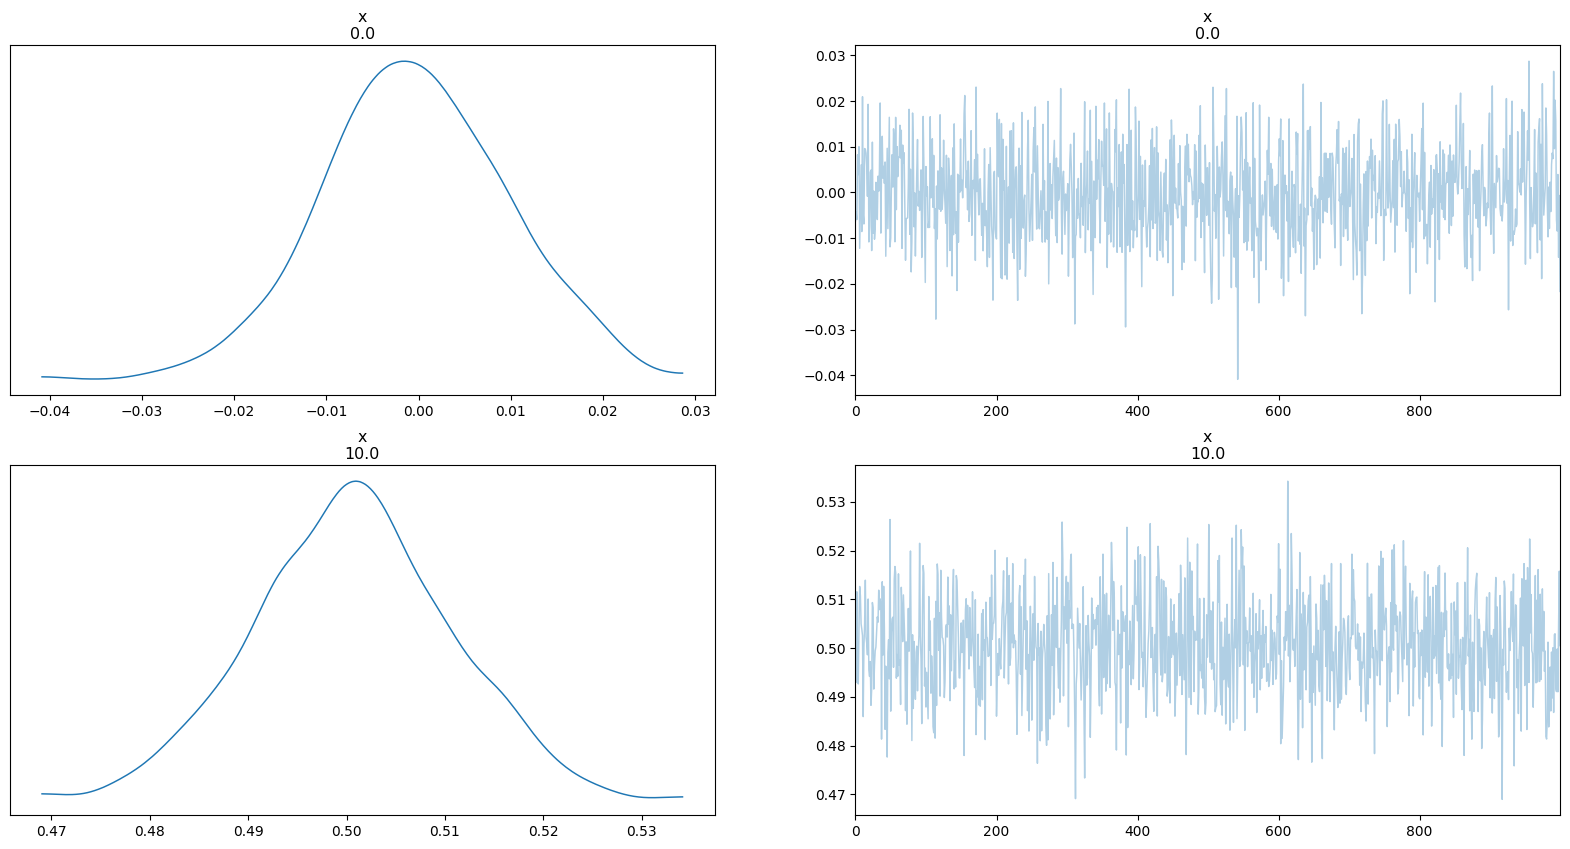

In [ ]:
axes = az.plot_trace(idata, var_names=["x"], coords={"time": [0., 10.]},compact=False, figsize=(20, 10))

In [ ]:
az.plot_autocorr(idata, coords={'time': [0.0, 10.0]}, figsize=(20, 10), max_lag=10)

TypeError: plot_autocorr() got an unexpected keyword argument 'coords'